In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("new_insurance_data.csv")
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [42]:
df.isnull().sum()

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [43]:
df.isnull().sum().sum()

52

Removing all null values because 52 of 1338 is negligile

In [44]:
df.dropna(inplace=True)

In [45]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [46]:
df.shape

(1287, 13)

In [47]:
df.duplicated().sum()

0

No duplicate values and now check for outliers

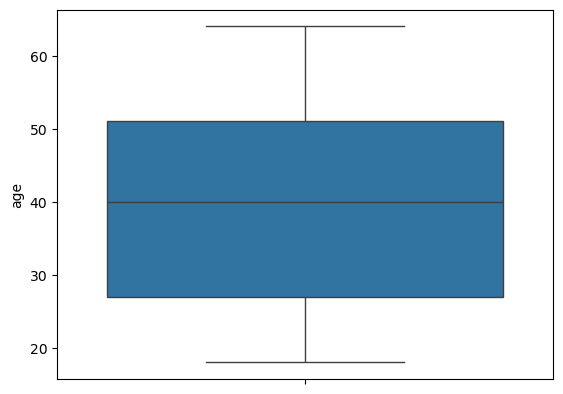

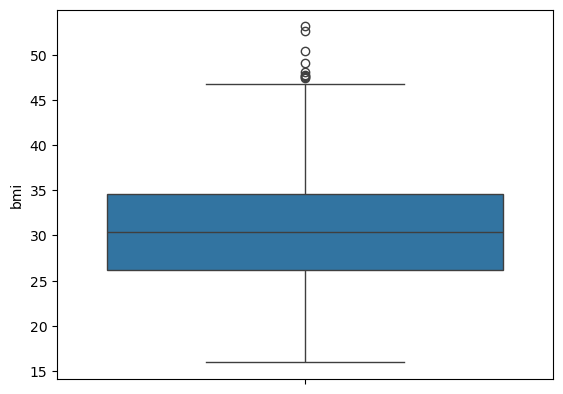

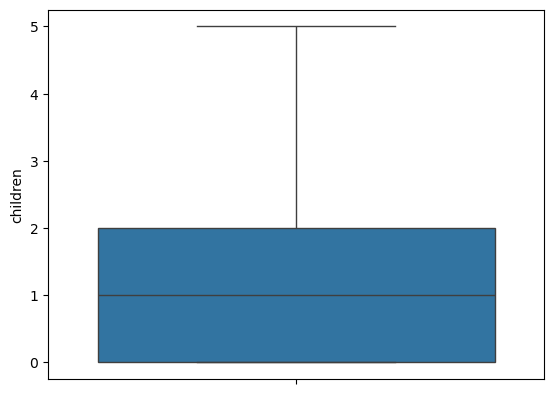

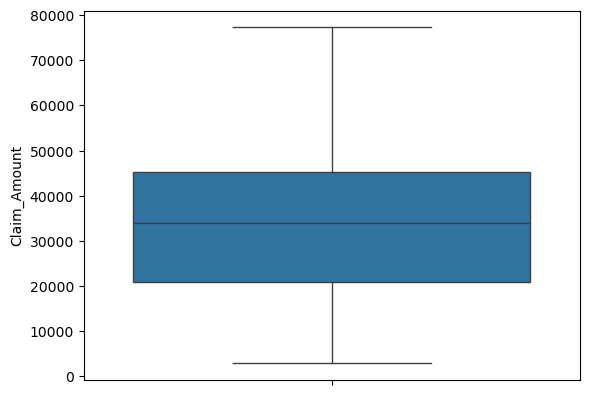

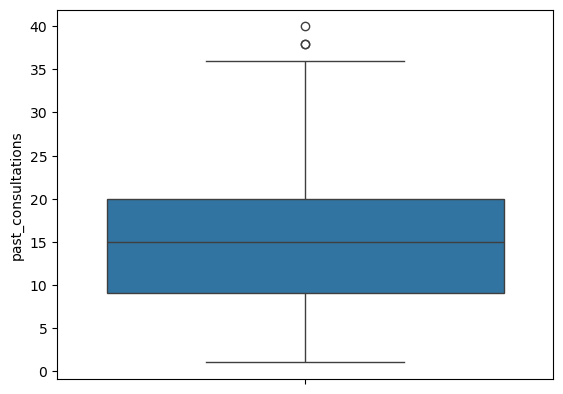

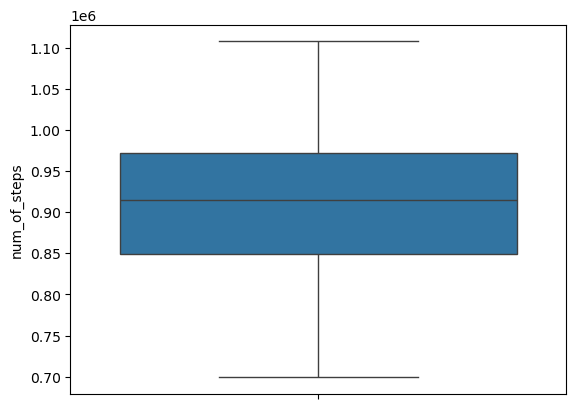

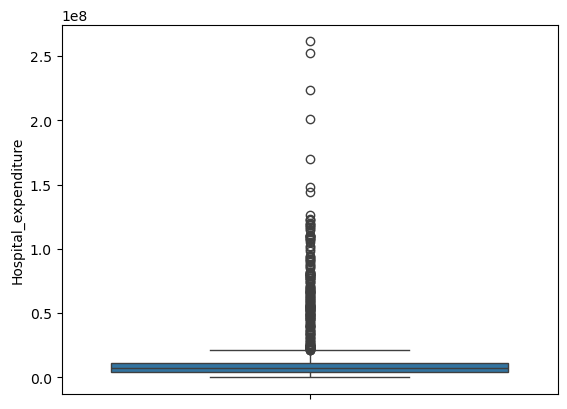

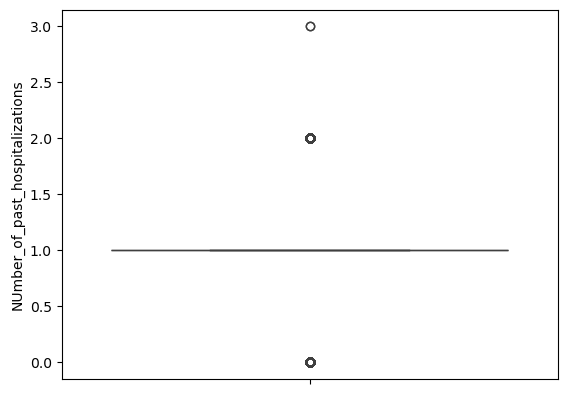

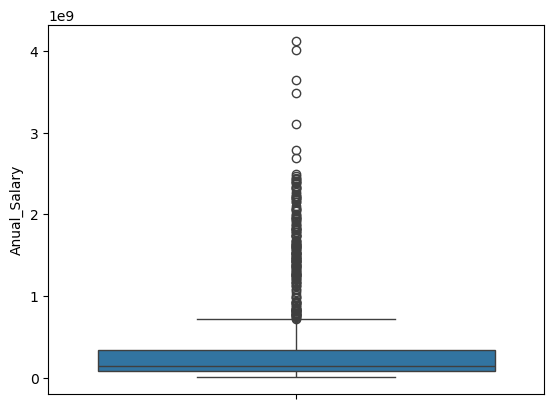

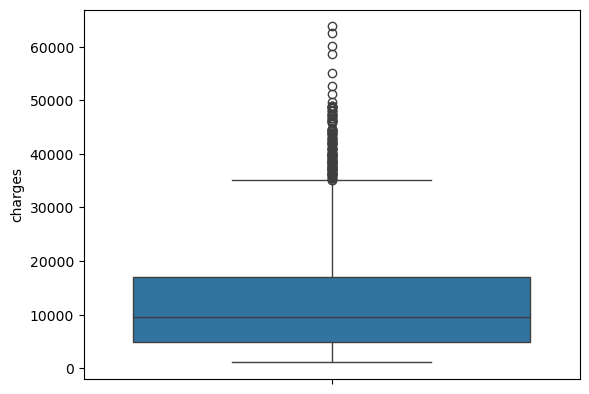

In [48]:
for col in df.columns:
  if df[col].dtype!='object':
    sns.boxplot(df[col])
    plt.show()

Outliers are found at bmi, past_consultations, Hospital_expenditure, Annual_Salary, Charges

In [49]:
out_cols=["bmi", "past_consultations", "Hospital_expenditure", "Anual_Salary", "charges"]

In [50]:
for col in out_cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  IQR=q3-q1
  upper_limit=q3+1.5*IQR
  lower_limit=q1-1.5*IQR
  df=df[(df[col]>=lower_limit)&(df[col]<=upper_limit)]

In [51]:
print(df[['Hospital_expenditure','Anual_Salary']].head())
print(df.dtypes)

   Hospital_expenditure  Anual_Salary
0           4720920.992   55784970.05
1           4329831.676   13700885.19
2           6884860.774   73523107.27
3           4274773.550   75819679.60
4           3787293.921   23012320.01
age                                float64
sex                                 object
bmi                                float64
children                           float64
smoker                              object
Claim_Amount                       float64
past_consultations                 float64
num_of_steps                       float64
Hospital_expenditure               float64
NUmber_of_past_hospitalizations    float64
Anual_Salary                       float64
region                              object
charges                            float64
dtype: object


In [52]:
X=df.drop("charges",axis=1)
y=df["charges"]

Outliers are also removed

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [54]:
categorical_cols = ['sex', 'smoker', 'region']

encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [55]:
X_encoded = encoder.fit_transform(X)

In [56]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,43.0,male,20.13,2.0,yes,44184.65414,19.0,984247.0,1.473451e+07,1.0,3.687871e+08,southeast,18767.73770
1041,24.0,female,27.60,0.0,no,27184.27803,9.0,980010.0,1.266673e+07,1.0,3.743228e+08,southwest,18955.22017
1046,29.0,female,27.94,1.0,yes,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08,southeast,19107.77960
1048,31.0,male,25.90,3.0,yes,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08,southwest,19199.94400


In [57]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region']
       based on these columns, charges are calculated

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [60]:
import pickle

pickle.dump(encoder, open('encoder.pkl', 'wb'))
pickle.dump(lr, open('insurance_model.pkl', 'wb'))

print("Saved successfully")

Saved successfully


In [61]:
y_pred=lr.predict(X_test)
y_pred

array([ 9118.63482769,  6658.69480796,  9956.30997594,  6688.85799243,
        5814.47528475,  8932.38991236, 10243.14420063,  4324.16924496,
        9570.61462968,  7136.74888824,  6432.62953495,  8717.35052278,
       11029.39495549, 14221.98755758,  4977.86320745,  3397.34737025,
        6581.30926223, 10536.42492752, 11241.52892666,  3003.25546169,
        1427.28450769,  1042.76956008, 12647.98681206,  3076.85950318,
        9787.44837146,  8211.5339473 ,  5652.62996796,  5314.82106403,
        1423.42392649,  5959.64701495,  2477.64496676,   578.84192796,
        6413.96654863,  4318.32114841, 13616.1129122 ,  1974.57239072,
        5708.66813822,  1557.24245192,  2332.32198437,  7461.57084348,
        4404.79622592,  2736.07693877,  8748.962055  ,  4376.17524585,
        8741.23130511,  9638.806602  ,  8942.97317987,  6719.47024092,
        5560.61746714,  8554.81259396, 11280.30032735,  6880.30156335,
       11161.03256223, 11684.85227868,  8162.59351341, 10280.78420873,
      

In [62]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)*100

96.87153785327573

Model is having R^2 score as 96.92%

Let us check charges for new entity

In [63]:
new_df=pd.DataFrame(columns=X.columns)
new_df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region


In [64]:
row=[]
for col in new_df.columns:
  k=input(f"Enter {col}: ")
  row.append(k)

In [65]:
row

['45',
 'male',
 '28.1',
 '2',
 'yes',
 '500000',
 '11',
 '789456',
 '500000',
 '2',
 '800000',
 'southeast']

In [66]:
new_df.loc[0]=row
new_df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,45,male,28.1,2,yes,500000,11,789456,500000,2,800000,southeast


In [67]:
new_df=new_df.dropna()

In [68]:
new_df['Hospital_expenditure_sci'] = df['Hospital_expenditure'].apply(lambda x: f"{x:.6e}")
new_df['Anual_Salary_sci'] = df['Anual_Salary'].apply(lambda x: f"{x:.6e}")

In [69]:
new_df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,Hospital_expenditure_sci,Anual_Salary_sci
0,45,male,28.1,2,yes,500000,11,789456,500000,2,800000,southeast,4.720921e+06,5.578497e+07


In [70]:
new_df['Hospital_expenditure']=new_df['Hospital_expenditure_sci']
new_df['Anual_Salary']=new_df['Anual_Salary_sci']

In [71]:
new_df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,Hospital_expenditure_sci,Anual_Salary_sci
0,45,male,28.1,2,yes,500000,11,789456,4.720921e+06,2,5.578497e+07,southeast,4.720921e+06,5.578497e+07


In [72]:
new_df=new_df.drop(['Hospital_expenditure_sci','Anual_Salary_sci'],axis=1)
new_df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region
0,45,male,28.1,2,yes,500000,11,789456,4.720921e+06,2,5.578497e+07,southeast


In [73]:
new_df['Hospital_expenditure']=new_df['Hospital_expenditure'].astype(float)
new_df['Anual_Salary']=new_df['Anual_Salary'].astype(float)

In [74]:
new_df_encoded = encoder.transform(new_df)

In [75]:
y_pred_new = lr.predict(new_df_encoded)
y_pred_new=max(y_pred_new, 0)
y_pred_new

array([1852.38937519])

In [76]:
import pickle

with open('insurance_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

print("Saved successfully")

Saved successfully
